   sepal length (cm)  sepal width (cm)  petal length (cm)  petal width (cm)
0                5.1               3.5                1.4               0.2
1                4.9               3.0                1.4               0.2
2                4.7               3.2                1.3               0.2
3                4.6               3.1                1.5               0.2
4                5.0               3.6                1.4               0.2
   petal length (cm)  petal width (cm)
0                1.4               0.2
1                1.4               0.2
2                1.3               0.2
3                1.5               0.2
4                1.4               0.2
[[0.06779661 0.04166667]
 [0.06779661 0.04166667]
 [0.05084746 0.04166667]
 [0.08474576 0.04166667]
 [0.06779661 0.04166667]
 [0.11864407 0.125     ]
 [0.06779661 0.08333333]
 [0.08474576 0.04166667]
 [0.06779661 0.04166667]
 [0.08474576 0.        ]
 [0.08474576 0.04166667]
 [0.10169492 0.04166667]
 [0.067796

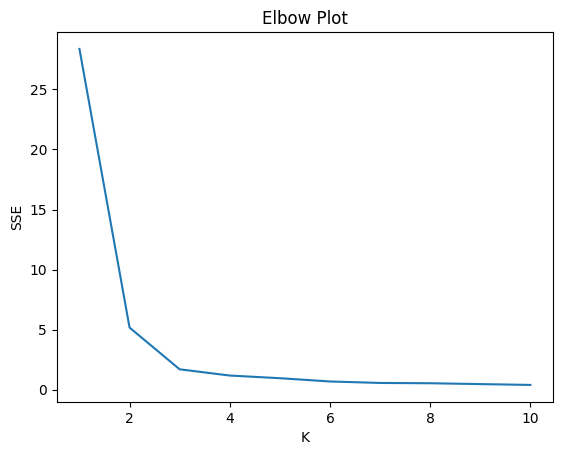

[1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1
 1 1 1 1 1 1 1 1 1 1 1 1 1 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 0 2 2 2
 2 2 2 0 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 0 0 0 0 0 0 2 0 0 0 0
 0 0 0 0 0 0 0 0 2 0 0 0 0 0 0 0 0 0 0 0 0 0 2 2 0 0 0 0 0 0 0 0 0 0 0 0 0
 0 0]
   petal length (cm)  petal width (cm)  cluster
0                1.4               0.2        1
1                1.4               0.2        1
2                1.3               0.2        1
3                1.5               0.2        1
4                1.4               0.2        1


In [1]:
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.datasets import load_iris
from sklearn.cluster import KMeans
from sklearn.preprocessing import MinMaxScaler
iris = load_iris()
df = pd.DataFrame(
    iris.data,
    columns=iris.feature_names
)
print(df.head())
df = df[[
    'petal length (cm)',
    'petal width (cm)'
]]
print(df.head())
scaler = MinMaxScaler()
scaler.fit(df)
df_scaled = scaler.transform(df)
print(df_scaled)
sse = []
k_range = range(1, 11)
for k in k_range:
    model = KMeans(
        n_clusters=k,
        random_state=42
    )
    model.fit(df_scaled)

    sse.append(model.inertia_)
print(sse)
plt.plot(k_range, sse)
plt.xlabel("K")
plt.ylabel("SSE")
plt.title("Elbow Plot")
plt.show()
model = KMeans(
    n_clusters=3,
    random_state=42
)
prediction = model.fit_predict(df_scaled)
print(prediction)
df['cluster'] = prediction
print(df.head())